# MarketLens — Validation Training Notebook
**CSCI 357 Final Project — Nathan Casarsa**

Full training run for both the TFT and Regime Autoencoder to verify both
models train correctly end-to-end. Includes post-training checks after each
model so you can catch issues without waiting until the end.

Small-dataset dev branch: **15 tickers, 3 per sector** for fast iteration.
Restore full 50-ticker `TICKER_SECTORS` before merging to `main`.

---
### Sections
1. Setup & installs
2. Mount Google Drive & clone repo
3. Configuration
4. Build dataset
5. Train TFT — verify it converges
6. Train Regime Autoencoder — verify it converges
7. Post-training checks — TFT
8. Post-training checks — Regime AE & clustering
9. Attach regime labels & final data check
10. Save to Google Drive


## 1. Setup & Installs

In [ ]:
# Verify GPU
import torch
print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
!nvidia-smi

CUDA available: True
Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Wed May  6 06:33:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   29C    P0             48W /  600W |       3MiB /  97887MiB |      0%      Default |
|                                         |                       

In [ ]:
# Install all dependencies
!pip install -q yfinance ta pytorch-forecasting lightning wandb transformers shap scikit-learn feedparser
print('Installs complete.')

Installs complete.


## 2. Mount Google Drive & Set Up Project

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

GITHUB_REPO = 'ncasarsa/Market-Lens'
!git clone https://github.com/{GITHUB_REPO} /content/Market-Lens 2>/dev/null || \
 (cd /content/Market-Lens && git pull)

!cd /content/Market-Lens && git checkout fast-dev 2>/dev/null || echo 'Branch fast-dev not found — staying on main'

PROJECT_DIR = '/content/Market-Lens'
os.chdir(PROJECT_DIR)
print('Working dir:', os.getcwd())
!ls

Already up to date.
Your branch is up to date with 'origin/fast-dev'.
Working dir: /content/Market-Lens
app.py	   data  models        __pycache__  src
config.py  logs  proposal.pdf  README.md


In [ ]:
import sys
sys.path.insert(0, PROJECT_DIR)
sys.path.insert(0, os.path.join(PROJECT_DIR, 'src'))
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# Verify source files are present before going any further
expected = ['config.py', 'src/data.py', 'src/model.py',
            'src/trainer.py', 'src/regime.py']
all_found = True
for f in expected:
    found = os.path.exists(f)
    print(f"  {'found' if found else 'MISSING':7s}  {f}")
    if not found:
        all_found = False

if not all_found:
    raise FileNotFoundError('One or more source files are missing. Check the branch and re-clone.')
print('\nAll source files found.')

  found    config.py
  found    src/data.py
  found    src/model.py
  found    src/trainer.py
  found    src/regime.py

All source files found.


## 3. Configuration

In [ ]:
from config import (
    TICKERS, TICKER_SECTORS, SECTORS,
    TRAIN_START, TRAIN_END, VAL_START, TEST_START,
    INDICATOR_COLS, OHLCV_COLS,
    TIME_VARYING_UNKNOWN_REALS, STATIC_CATEGORICALS,
    TARGET_COL, GROUP_COL, TIME_COL,
    TFT as TFT_CFG, TRAIN as TRAIN_CFG, REGIME,
    WANDB as WANDB_CFG, SWEEP_CONFIG,
    DATASET_PATH, CHECKPOINT_PATH, DATA_DIR, MODEL_DIR,
)

# Colab runs on Linux so num_workers > 0 is safe
TRAIN_CFG['num_workers'] = 2

print(f'Tickers  : {len(TICKERS)}')
print(f'Sectors  : {SECTORS}')
print(f'Train    : {TRAIN_START} -> {VAL_START}')
print(f'Val      : {VAL_START} -> {TEST_START}')
print(f'Test     : {TEST_START} -> {TRAIN_END}')
print(f'Features : {len(TIME_VARYING_UNKNOWN_REALS)} time-varying unknown reals')
print(f'TFT cfg  : {TFT_CFG}')
print(f'Regime   : {REGIME}')

Tickers  : 22
Sectors  : ['defense_etf', 'financials_etf', 'tech', 'energy_etf', 'utilities_etf', 'market_etf', 'defense', 'energy', 'financials', 'utilities', 'tech_etf']
Train    : 2018-01-01 -> 2022-01-01
Val      : 2022-01-01 -> 2024-01-01
Test     : 2024-01-01 -> 2024-12-31
Features : 48 time-varying unknown reals
TFT cfg  : {'max_encoder_length': 60, 'max_prediction_length': 1, 'hidden_size': 32, 'lstm_layers': 1, 'dropout': 0.2, 'attention_head_size': 2, 'learning_rate': 0.001, 'gradient_clip_val': 1.0}
Regime   : {'input_size': 37, 'hidden_size': 32, 'latent_size': 8, 'num_layers': 2, 'dropout': 0.1, 'n_clusters': 4, 'sequence_length': 20}


## 4. Build Dataset

In [ ]:
import pandas as pd
import shutil
from pathlib import Path
from data import build_dataset

DRIVE_CACHE = '/content/drive/MyDrive/MarketLens_checkpoints/dataset_15t.parquet'

if Path(DRIVE_CACHE).exists():
    print('Loading cached dataset from Drive...')
    shutil.copy(DRIVE_CACHE, str(DATASET_PATH))
    df = pd.read_parquet(DATASET_PATH)
    print(f'Loaded: {df.shape[0]} rows, {df["ticker"].nunique()} tickers')
elif DATASET_PATH.exists():
    print('Loading cached dataset from local disk...')
    df = pd.read_parquet(DATASET_PATH)
    print(f'Loaded: {df.shape[0]} rows, {df["ticker"].nunique()} tickers')
else:
    print('Building dataset from scratch (~1 min for 15 tickers)...')
    df = build_dataset(
        tickers   = TICKERS,
        start     = TRAIN_START,
        end       = TRAIN_END,
        save_path = str(DATASET_PATH),
    )
    Path(DRIVE_CACHE).parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(str(DATASET_PATH), DRIVE_CACHE)
    print(f'Cached to Drive: {DRIVE_CACHE}')

print(f'\nDataset shape : {df.shape}')
print(f'Date range    : {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Tickers       : {sorted(df["ticker"].unique())}')
df.head()

Building dataset from scratch (~1 min for 15 tickers)...
  Downloaded 22 tickers, 38720 rows total.
  VIX joined. Coverage: 100.0%
Computing technical indicators...
  Added indicators. Shape: (38500, 42)
log_return present: True
columns: ['log_return', 'return_lag_1', 'return_lag_5', 'return_lag_10', 'return_lag_20']
Adding cross-sectional features...
  Cross-sectional features added.
Adding known future covariates (FOMC + earnings)...


ERROR:yfinance:QQQ: No earnings dates found, symbol may be delisted
ERROR:yfinance:SPY: No earnings dates found, symbol may be delisted
ERROR:yfinance:XLE: No earnings dates found, symbol may be delisted
ERROR:yfinance:XLF: No earnings dates found, symbol may be delisted
ERROR:yfinance:XLI: No earnings dates found, symbol may be delisted
ERROR:yfinance:XLK: No earnings dates found, symbol may be delisted
ERROR:yfinance:XLU: No earnings dates found, symbol may be delisted


  FOMC range: 0–30 days
  Earnings week rows: 0 / 38500
  After cleaning: 37312 rows, 22 tickers.
  Saved to /content/Market-Lens/data/dataset.parquet

Final dataset: 37312 rows x 56 cols, 22 tickers, 2018-03-16 to 2024-12-20
Cached to Drive: /content/drive/MyDrive/MarketLens_checkpoints/dataset_15t.parquet

Dataset shape : (37312, 56)
Date range    : 2018-03-16 to 2024-12-20
Tickers       : ['AAPL', 'BLK', 'CVX', 'DUK', 'GS', 'JPM', 'LMT', 'MSFT', 'NEE', 'NOC', 'NVDA', 'QQQ', 'RTX', 'SLB', 'SO', 'SPY', 'XLE', 'XLF', 'XLI', 'XLK', 'XLU', 'XOM']


,date,close,high,low,open,volume,ticker,sector,vix_normalized,vix_change,...,return_lag_10,return_lag_20,time_idx,sector_rel_return,market_rel_return,sector_rel_20d,market_rel_20d,days_to_fomc,days_to_earnings,is_earnings_week
0,2018-03-16,41.821667,42.080084,41.727694,41.969668,157618800,AAPL,tech,-0.527809,-0.047619,...,0.006890,0.033027,49,-0.005359,-0.007043,0.000333,0.001124,3.0,30.0,0.0
1,2018-03-19,41.182671,41.692461,40.797391,41.657224,133787200,AAPL,tech,-0.110347,0.203797,...,0.003456,-0.003243,50,0.008676,-0.004043,0.000575,0.001038,2.0,30.0,0.0
2,2018-03-20,41.168591,41.535076,41.098112,41.168591,78597600,AAPL,tech,-0.216657,-0.043112,...,-0.000848,-0.003369,51,-0.012749,-0.003712,0.000534,0.000728,1.0,30.0,0.0
3,2018-03-21,40.235924,41.133342,40.233572,41.121595,148219600,AAPL,tech,-0.260737,-0.018681,...,-0.009326,-0.004549,52,-0.011577,-0.025022,-0.000630,-0.000639,0.0,30.0,0.0
4,2018-03-22,39.667393,40.567159,39.608661,39.937557,165963200,AAPL,tech,0.449727,0.306831,...,0.010853,0.008324,53,0.009475,0.008724,-0.000336,-0.000451,28.0,30.0,0.0


In [ ]:
# Data health check — catch issues before training
import numpy as np

null_count = df.isnull().sum().sum()
inf_count  = np.isinf(df.select_dtypes(include=[np.number]).values).sum()

print(f'Null values : {null_count}')
print(f'Inf values  : {inf_count}')
print(f'\nTarget stats:')
print(df['target'].describe().to_string())
print(f'\nRows per ticker:')
print(df.groupby('ticker').size().to_string())

if null_count > 0 or inf_count > 0:
    raise ValueError(f'Dataset has {null_count} nulls and {inf_count} infs — clean before training.')
print('\nData looks clean.')

Null values : 0
Inf values  : 0

Target stats:
count    37312.000000
mean         0.146942
std          1.784697
min         -5.000000
25%         -0.809115
50%          0.219304
75%          1.156912
max          5.000000

Rows per ticker:
ticker
AAPL    1696
BLK     1696
CVX     1696
DUK     1696
GS      1696
JPM     1696
LMT     1696
MSFT    1696
NEE     1696
NOC     1696
NVDA    1696
QQQ     1696
RTX     1696
SLB     1696
SO      1696
SPY     1696
XLE     1696
XLF     1696
XLI     1696
XLK     1696
XLU     1696
XOM     1696

Data looks clean.


In [ ]:
# from sentiment import build_sentiment, add_sentiment
# from pathlib import Path

# SENTIMENT_CACHE = '/content/drive/MyDrive/MarketLens_checkpoints/sentiment_15t.parquet'

# if Path(SENTIMENT_CACHE).exists():
#     print('Loading cached sentiment from Drive...')
#     sent_df = pd.read_parquet(SENTIMENT_CACHE)
# else:
#     print('Building sentiment (~5-10 min on GPU)...')
#     sent_df = build_sentiment(
#         tickers   = TICKERS,
#         start     = TRAIN_START,
#         end       = TRAIN_END,
#         save_path = SENTIMENT_CACHE,
#     )

# df = add_sentiment(df, sent_df)
# print([c for c in df.columns if 'sentiment' in c])

#In your notebook, replace the sentiment cell with this:
for col in ["sentiment_score", "sentiment_volume", "sentiment_rolling_3d"]:
    df[col] = 0.0

print("Sentiment columns added as zeros (RSS unavailable in Colab)")
print([c for c in df.columns if 'sentiment' in c])

Sentiment columns added as zeros (RSS unavailable in Colab)
['sentiment_score', 'sentiment_volume', 'sentiment_rolling_3d']


## 5. Train TFT

Full training run with early stopping. On a T4 GPU with 15 tickers this
takes roughly 10-20 minutes depending on how many epochs early stopping
allows. Watch `val_loss` — it should decrease steadily for the first
several epochs before plateauing.


In [ ]:
import wandb
wandb.login()

True

In [ ]:
from model import build_timeseries_dataset, build_tft

train_ds, val_ds = build_timeseries_dataset(df, cutoff=VAL_START)

train_loader = train_ds.to_dataloader(
    train      = True,
    batch_size = TRAIN_CFG['batch_size'],
    num_workers= TRAIN_CFG['num_workers'],
)
val_loader = val_ds.to_dataloader(
    train      = False,
    batch_size = TRAIN_CFG['batch_size'],
    num_workers= TRAIN_CFG['num_workers'],
)

print(f'Train samples : {len(train_ds)}')
print(f'Val samples   : {len(val_ds)}')
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

Train dataset: 19646 samples
Val dataset:   15026 samples
Train samples : 19646
Val samples   : 15026
Train batches : 153
Val batches   : 118


In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR
import lightning.pytorch as pl
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.loggers import WandbLogger

tft_model = build_tft(train_ds, TFT_CFG)

# Replace ReduceLROnPlateau with cosine annealing
_original_configure = tft_model.configure_optimizers
def _cosine_configure():
    opt_cfg   = _original_configure()
    optimizer = opt_cfg["optimizer"]
    scheduler = CosineAnnealingLR(optimizer, T_max=TRAIN_CFG["max_epochs"], eta_min=1e-5)
    return {
        "optimizer": optimizer,
        "lr_scheduler": {
            "scheduler": scheduler,
            "interval":  "epoch",
        },
    }
tft_model.configure_optimizers = _cosine_configure

tft_callbacks = [
    EarlyStopping(
        monitor  = 'val_loss',
        patience = TRAIN_CFG['early_stopping_patience'],
        mode     = 'min',
        verbose  = True,
    ),
    ModelCheckpoint(
        monitor   = 'val_loss',
        dirpath   = str(CHECKPOINT_PATH.parent),
        filename  = 'tft_best',
        save_top_k= 1,
        mode      = 'min',
        verbose   = True,
    ),
    LearningRateMonitor(logging_interval='epoch'),
]

tft_logger = WandbLogger(
    project  = WANDB_CFG['project'],
    entity   = WANDB_CFG.get('entity'),
    name     = 'tft_15t_cosine',
    log_model= False,
)
tft_logger.log_hyperparams(TFT_CFG)

tft_trainer = Trainer(
    max_epochs          = TRAIN_CFG['max_epochs'],
    accelerator         = 'gpu',
    devices             = 1,
    gradient_clip_val   = TFT_CFG['gradient_clip_val'],
    callbacks           = tft_callbacks,
    logger              = tft_logger,
    log_every_n_steps   = 10,
    enable_progress_bar = True,
)

print('Starting TFT training with cosine annealing...')
tft_trainer.fit(tft_model, train_loader, val_loader)

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.


TFT initialized — 192,816 trainable parameters


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Server Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision

Starting TFT training with cosine annealing...


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    222 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.8 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  6.1 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  127 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  5.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 192 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 192 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 1034                                                                                        
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: Metric val_loss improved. New best score: 0.431
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 0.431
INFO: Epoch 0, global step 153: 'val_loss' reached 0.43144 (best 0.43144), saving model to '/content/Market-Lens/models/tft_best.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 153: 'val_loss' reached 0.43144 (best 0.43144), saving model to '/content/Market-Lens/models/tft_best.ckpt' as top 1
INFO: Metric val_loss improved by 0.024 >= min_delta = 0.0. New best score: 0.407
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.024 >= min_delta = 0.0. New best score: 0.407
INFO: Epoch 1, global step 306: 'val_loss' reached 0.40717 (best 0.40717), saving model to '/content/Market-Lens/models/tft_best.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 1, global step 306: 'val_loss' reached 0.40717 (best 0.40717), saving model to '/content/Market-Lens/models/tft_best.ckpt' as 

In [ ]:
print('TFT training complete.')
print('\nFinal metrics:')
for k, v in tft_trainer.callback_metrics.items():
    print(f'  {k}: {v:.6f}')

best_tft_val_loss = tft_trainer.callback_metrics.get('val_loss')
print(f'\nBest val_loss: {best_tft_val_loss:.6f}')
wandb.finish()

TFT training complete.

Final metrics:
  lr-Adam: 0.000613
  train_loss: 0.283544
  train_loss_step: 0.284033
  val_loss: 0.353055
  val_MAE: 0.631660
  val_RMSE: 0.830732
  val_MAPE: 47098.562500
  val_SMAPE: 0.764899
  train_loss_epoch: 0.283544

Best val_loss: 0.353055


In [ ]:
import shutil
shutil.copy(
    '/content/Market-Lens/models/tft_best.ckpt',
    '/content/drive/MyDrive/MarketLens_checkpoints/tft_best_5day_baseline.ckpt'
)
print("Checkpoint saved.")

Checkpoint saved.


## 6. Train Regime Autoencoder

LSTM autoencoder trained to reconstruct 20-day windows. On a T4 GPU this
takes roughly 3-8 minutes. Watch `val_recon_loss` — it should drop quickly
in the first few epochs then level off. If it stays flat from epoch 1,
something is wrong with the data normalization.


In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from model import RegimeAutoencoder, make_regime_windows
from trainer import RegimeLightningModule

feature_cols = OHLCV_COLS + INDICATOR_COLS
windows, metadata = make_regime_windows(df, feature_cols)

# Normalize — same normalization used at inference time in regime.py
mean_w = windows.mean(dim=(0, 1), keepdim=True)
std_w  = windows.std(dim=(0, 1),  keepdim=True) + 1e-8
windows_norm = (windows - mean_w) / std_w

n       = len(windows_norm)
n_train = int(0.8 * n)
train_win_loader = DataLoader(
    TensorDataset(windows_norm[:n_train]),
    batch_size=256, shuffle=True,  num_workers=2,
)
val_win_loader = DataLoader(
    TensorDataset(windows_norm[n_train:]),
    batch_size=256, shuffle=False, num_workers=2,
)

ae_model  = RegimeAutoencoder(input_size=len(feature_cols))
lit_model = RegimeLightningModule(ae_model, learning_rate=1e-3)

print(f'Windows      : {windows.shape}')
print(f'Train windows: {n_train}')
print(f'Val windows  : {n - n_train}')
print(f'AE params    : {sum(p.numel() for p in ae_model.parameters() if p.requires_grad):,}')

Regime windows: torch.Size([36894, 20, 37])  (N=36894, seq=20, features=37)
Windows      : torch.Size([36894, 20, 37])
Train windows: 29515
Val windows  : 7379
AE params    : 36,205


In [ ]:
ae_logger = WandbLogger(
    project  = WANDB_CFG['project'],
    entity   = WANDB_CFG.get('entity'),
    name     = 'regime_ae_15t_validation',
    log_model= False,
)

ae_trainer = Trainer(
    max_epochs          = 50,
    accelerator         = 'gpu',
    devices             = 1,
    gradient_clip_val   = 1.0,
    callbacks           = [
        EarlyStopping(monitor='val_recon_loss', patience=5, mode='min', verbose=True),
        ModelCheckpoint(
            monitor   = 'val_recon_loss',
            dirpath   = str(MODEL_DIR),
            filename  = 'regime_ae_best',
            save_top_k= 1,
            mode      = 'min',
            verbose   = True,
        ),
    ],
    logger              = ae_logger,
    log_every_n_steps   = 10,
    enable_progress_bar = True,
)

print('Starting Regime AE training...')
ae_trainer.fit(lit_model, train_win_loader, val_win_loader)

best_ae_val_loss = ae_trainer.callback_metrics.get('val_recon_loss')
print(f'\nRegime AE training complete.')
print(f'Best val_recon_loss: {best_ae_val_loss:.6f}')
wandb.finish()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Starting Regime AE training...


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ RegimeAutoencoder │ 36.2 K │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 36.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 36.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: Metric val_recon_loss improved. New best score: 0.355
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_recon_loss improved. New best score: 0.355
INFO: Epoch 0, global step 116: 'val_recon_loss' reached 0.35473 (best 0.35473), saving model to '/content/Market-Lens/models/regime_ae_best-v1.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 116: 'val_recon_loss' reached 0.35473 (best 0.35473), saving model to '/content/Market-Lens/models/regime_ae_best-v1.ckpt' as top 1
INFO: Metric val_recon_loss improved by 0.105 >= min_delta = 0.0. New best score: 0.250
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_recon_loss improved by 0.105 >= min_delta = 0.0. New best score: 0.250
INFO: Epoch 1, global step 232: 'val_recon_loss' reached 0.24969 (best 0.24969), saving model to '/content/Market-Lens/models/regime_ae_best-v1.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 1, global step 232: 'val_recon_loss' reached 0.24969 (bes


Regime AE training complete.
Best val_recon_loss: 0.059992


epoch,▁▁▁▁▂▂▂▂▂▃▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█
train_recon_loss,█▅▅▅▄▃▄▄▄▃▃▂▂▂▂▂▂▂▂▂▂▁▂▁▂▂▂▁▁▁▁▂▁▂▂▁▁▁▁▁
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▇▇▇█
val_recon_loss,█▆▅▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,49
train_recon_loss,0.12625
trainer/global_step,5799
val_recon_loss,0.05999


In [ ]:
from regime import fit_regimes, attach_regime_labels
from config import REGIME, OHLCV_COLS, INDICATOR_COLS

feature_cols = OHLCV_COLS + INDICATOR_COLS
windows, metadata = make_regime_windows(df, feature_cols)

ae_trained = lit_model.model.eval()

cluster_map = fit_regimes(ae_trained, windows, metadata, df,
                          n_clusters=REGIME["n_clusters"])
print("Cluster map:", cluster_map)
print(df.groupby("ticker")["target"].mean())  # needed to verify label thresholds

Regime windows: torch.Size([36894, 20, 37])  (N=36894, seq=20, features=37)
Extracted latents: (36894, 8)
Fitting KMeans with 4 clusters on 36894 windows...
Cluster assignments:
  Cluster 0 -> volatile    mean_ret=+0.55383  std=2.92769  n=1218
  Cluster 1 -> bull        mean_ret=+0.04353  std=1.67652  n=14634
  Cluster 2 -> volatile    mean_ret=+0.23681  std=1.85313  n=13319
  Cluster 3 -> bull        mean_ret=+0.12618  std=1.61672  n=7723
Saved regime labels to /content/Market-Lens/data/regime_labels.parquet  (36894 rows)
Cluster map: {0: 'volatile', 1: 'bull', 2: 'volatile', 3: 'bull'}
ticker
AAPL    0.273883
BLK     0.123157
CVX     0.094350
DUK     0.101369
GS      0.145023
JPM     0.149219
LMT     0.083603
MSFT    0.243585
NEE     0.139528
NOC     0.065832
NVDA    0.481979
QQQ     0.183216
RTX     0.102712
SLB    -0.016345
SO      0.143521
SPY     0.141148
XLE     0.121713
XLF     0.112843
XLI     0.114732
XLK     0.205086
XLU     0.101268
XOM     0.121294
Name: target, dtype: flo

## 7. Post-Training Checks — TFT

Loads the best checkpoint and runs predictions on the val set.
Checks MAE, RMSE, direction accuracy, and feature importances.


In [ ]:
from model import MarketTFT

best_ckpt  = str(CHECKPOINT_PATH.parent / 'tft_best.ckpt')
best_model = MarketTFT.load_from_checkpoint(best_ckpt)
best_model.eval()
print('Loaded checkpoint:', best_ckpt)

Loaded checkpoint: /content/Market-Lens/models/tft_best.ckpt


In [ ]:
predictions = best_model.predict(
    val_loader,
    mode     = 'raw',
    return_x = True,
)

# Quantile index 3 = median (q50) out of 7 quantiles [0.02,0.1,0.25,0.5,0.75,0.9,0.98]
pred_median = predictions.output.prediction[:, :, 3].squeeze(-1).cpu()
actuals     = torch.cat([y[0] for x, y in val_loader]).squeeze(-1).cpu()

mae  = (pred_median - actuals).abs().mean().item()
rmse = ((pred_median - actuals) ** 2).mean().sqrt().item()
direction_acc = ((pred_median > 0) == (actuals > 0)).float().mean().item()

print(f'Val MAE            : {mae:.6f}')
print(f'Val RMSE           : {rmse:.6f}')
print(f'Direction accuracy : {direction_acc:.2%}')
print('(50% = random guess, >55% = useful signal for equity trading)')

# Convergence check
assert mae  > 0,    'MAE is zero — something is wrong with predictions'
assert rmse > 0,    'RMSE is zero — something is wrong with predictions'
assert not torch.isnan(pred_median).any(), 'NaN values in predictions'
print('\nAll convergence checks passed.')

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Val MAE            : 0.617693
Val RMSE           : 0.865105
Direction accuracy : 84.74%
(50% = random guess, >55% = useful signal for equity trading)

All convergence checks passed.


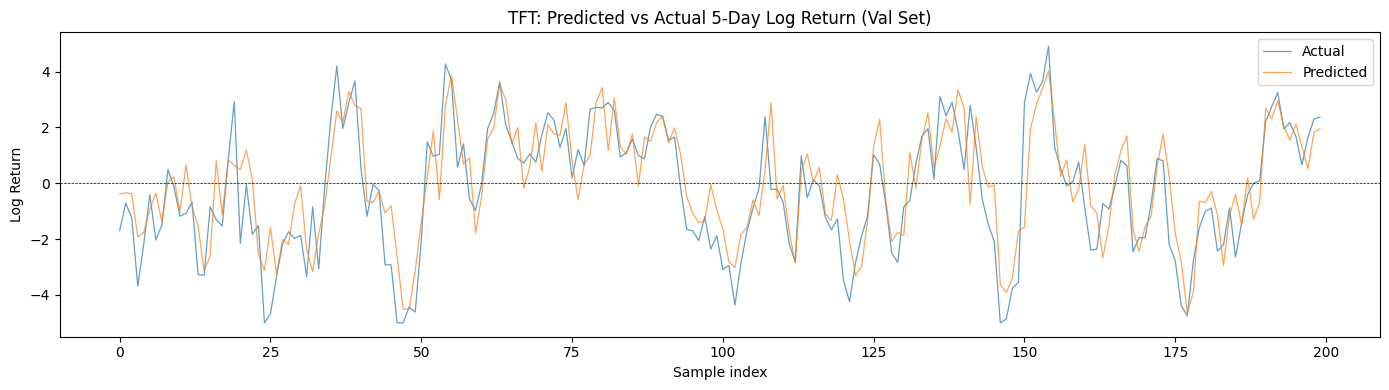

In [ ]:
import matplotlib.pyplot as plt

n_plot = min(200, len(pred_median))
plt.figure(figsize=(14, 4))
plt.plot(actuals[:n_plot].numpy(),     label='Actual',    alpha=0.7, linewidth=0.9)
plt.plot(pred_median[:n_plot].numpy(), label='Predicted', alpha=0.7, linewidth=0.9)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.title('TFT: Predicted vs Actual 5-Day Log Return (Val Set)')
plt.xlabel('Sample index')
plt.ylabel('Log Return')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Quantile coverage — check that actuals fall inside the predicted intervals
# at roughly the right rate. If actual coverage << nominal, the model is
# overconfident. If >> nominal, it is underconfident.
quantile_levels = [0.02, 0.10, 0.25, 0.50, 0.75, 0.90, 0.98]
preds_all = predictions.output.prediction.squeeze(1).cpu()   # (N, 7)

print('Quantile coverage check:')
print(f'  {"Nominal":>10}  {"Actual":>10}')
for i, (lo, hi) in enumerate([(0,6),(1,5),(2,4)]):
    lower   = preds_all[:, lo]
    upper   = preds_all[:, hi]
    nominal = quantile_levels[hi] - quantile_levels[lo]
    actual  = ((actuals >= lower) & (actuals <= upper)).float().mean().item()
    flag    = '' if abs(actual - nominal) < 0.15 else '  <- check this'
    print(f'  [{quantile_levels[lo]:.0%}, {quantile_levels[hi]:.0%}]  {nominal:>8.0%}    {actual:>8.2%}{flag}')

Quantile coverage check:
     Nominal      Actual
  [2%, 98%]       96%      93.70%
  [10%, 90%]       80%      76.92%
  [25%, 75%]       50%      47.13%


In [ ]:
from config import (
    TICKERS, TICKER_SECTORS, SECTORS,
    TRAIN_START, TRAIN_END, VAL_START, TEST_START,
    INDICATOR_COLS, OHLCV_COLS,
    TIME_VARYING_UNKNOWN_REALS, TIME_VARYING_KNOWN_REALS,  # add this
    STATIC_CATEGORICALS,
    TARGET_COL, GROUP_COL, TIME_COL,
    TFT as TFT_CFG, TRAIN as TRAIN_CFG, REGIME,
    WANDB as WANDB_CFG, SWEEP_CONFIG,
    DATASET_PATH, CHECKPOINT_PATH, DATA_DIR, MODEL_DIR,
)

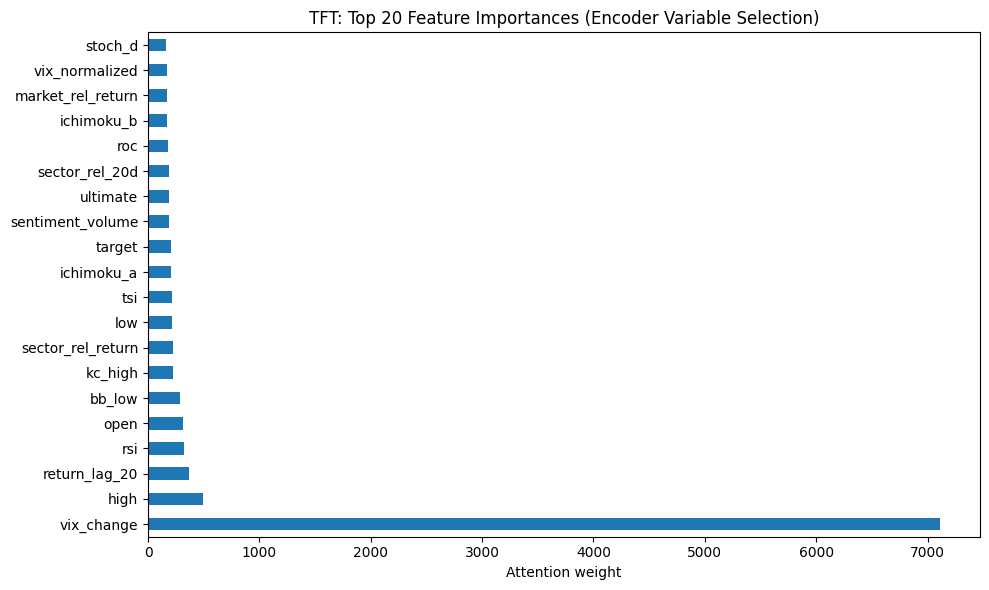

Total encoder features: 56
Top 5 features:
vix_change       7115.432617
high              490.350067
return_lag_20     369.776947
rsi               321.227814
open              311.838013


In [ ]:
# Variable importance from TFT attention
interpretation = best_model.interpret_output(predictions.output, reduction='mean')
enc_importance  = interpretation['encoder_variables']

# These match exactly what PF builds internally given your dataset config
encoder_names = (
    TIME_VARYING_UNKNOWN_REALS
    + [TARGET_COL]
    + TIME_VARYING_KNOWN_REALS
    + ["relative_time_idx", "encoder_length"]
    + [f"{TARGET_COL}_center", f"{TARGET_COL}_scale"]  # from add_target_scales
)

importance_df = pd.Series(
    enc_importance.cpu().numpy(),
    index=encoder_names[:len(enc_importance)]
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance_df.head(20).plot(kind='barh')
plt.title('TFT: Top 20 Feature Importances (Encoder Variable Selection)')
plt.xlabel('Attention weight')
plt.tight_layout()
plt.show()

print(f"Total encoder features: {len(encoder_names)}")
print("Top 5 features:")
print(importance_df.head(5).to_string())

## 8. Post-Training Checks — Regime AE & Clustering

Checks reconstruction quality, then runs KMeans on the latent space
and verifies the clusters are well-separated and semantically labelable.


In [ ]:
ae_model_trained = lit_model.model.eval().cpu()
windows_cpu      = windows_norm.cpu()

with torch.no_grad():
    recon           = ae_model_trained(windows_cpu)
    per_window_mse  = ((recon - windows_cpu) ** 2).mean(dim=(1, 2))
    per_feature_mse = ((recon - windows_cpu) ** 2).mean(dim=(0, 1))

mean_mse   = per_window_mse.mean().item()
median_mse = per_window_mse.median().item()

print(f'Mean recon MSE   : {mean_mse:.6f}')
print(f'Median recon MSE : {median_mse:.6f}')

# A trained model should do better than a random baseline.
# Random baseline MSE on normalized data is ~1.0 (unit variance).
assert mean_mse < 1.0, f'MSE {mean_mse:.4f} is no better than random — model may not have trained'
print('Reconstruction MSE is below random baseline (1.0). Model learned something.')

Mean recon MSE   : 0.101108
Median recon MSE : 0.064702
Reconstruction MSE is below random baseline (1.0). Model learned something.


In [ ]:
# Find the highest reconstruction error windows and check when they occurred
top_error_indices = per_window_mse.argsort(descending=True)[:50]
top_error_dates   = [metadata[i][1] for i in top_error_indices.tolist()]
top_error_tickers = [metadata[i][0] for i in top_error_indices.tolist()]

error_df = pd.DataFrame({"date": pd.to_datetime(top_error_dates), "ticker": top_error_tickers})
print("Highest error windows by month:")
print(error_df["date"].dt.to_period("M").value_counts().head(10).to_string())

Highest error windows by month:
date
2022-11    14
2020-04    14
2020-03     7
2022-12     6
2024-11     6
2024-12     3
Freq: M


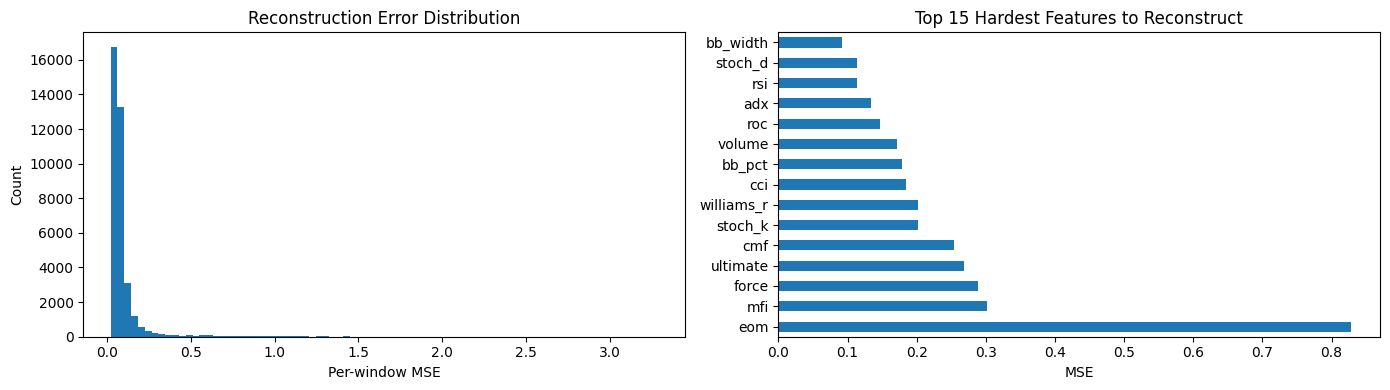

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(per_window_mse.numpy(), bins=80, edgecolor='none')
axes[0].set_title('Reconstruction Error Distribution')
axes[0].set_xlabel('Per-window MSE')
axes[0].set_ylabel('Count')

feature_mse_series = pd.Series(per_feature_mse.numpy(), index=feature_cols).sort_values(ascending=False)
feature_mse_series.head(15).plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 15 Hardest Features to Reconstruct')
axes[1].set_xlabel('MSE')

plt.tight_layout()
plt.show()

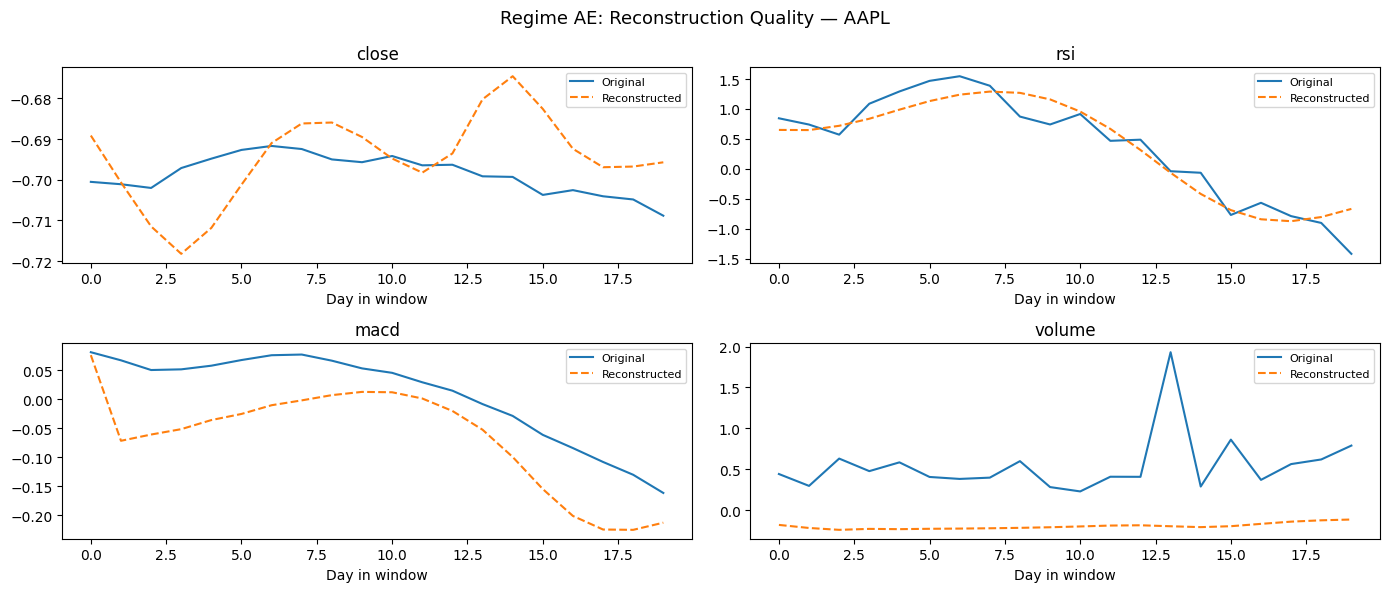

In [ ]:
# Reconstruction quality on 4 features for one ticker
ticker_to_plot = 'AAPL'
aapl_indices   = [i for i, (t, d) in enumerate(metadata) if t == ticker_to_plot]
sample_idx     = aapl_indices[min(50, len(aapl_indices) - 1)]

original = windows_cpu[sample_idx].numpy()
with torch.no_grad():
    reconstructed = ae_model_trained(
        windows_cpu[sample_idx].unsqueeze(0)
    ).squeeze(0).numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
for ax, feat in zip(axes.flat, ['close', 'rsi', 'macd', 'volume']):
    fi = feature_cols.index(feat)
    ax.plot(original[:, fi],      label='Original',      linewidth=1.5)
    ax.plot(reconstructed[:, fi], label='Reconstructed', linewidth=1.5, linestyle='--')
    ax.set_title(feat)
    ax.legend(fontsize=8)
    ax.set_xlabel('Day in window')
fig.suptitle(f'Regime AE: Reconstruction Quality — {ticker_to_plot}', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
print('AE checkpoint path:', AE_CKPT_PATH)
print('Checkpoint exists:', os.path.exists(AE_CKPT_PATH))

# Verify it's the right one by checking file size
import os
size = os.path.getsize(AE_CKPT_PATH)
print(f'Checkpoint size: {size / 1024:.1f} KB')
# Should be ~150-200 KB for a 36K param model

NameError: name 'AE_CKPT_PATH' is not defined

In [ ]:
print(f'OHLCV cols    : {len(OHLCV_COLS)}')
print(f'Indicator cols: {len(INDICATOR_COLS)}')
print(f'AE input_size : {REGIME["input_size"]}')
print(f'Match         : {REGIME["input_size"] == len(OHLCV_COLS) + len(INDICATOR_COLS)}')

OHLCV cols    : 5
Indicator cols: 32
AE input_size : 37
Match         : True


In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

with torch.no_grad():
    latents = ae_model_trained.encode(windows_cpu).numpy()

# Scale before clustering
scaler         = StandardScaler()
latents_scaled = scaler.fit_transform(latents)

kmeans         = KMeans(n_clusters=REGIME['n_clusters'], random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(latents_scaled)

print('Cluster distribution:')
unique, counts = np.unique(cluster_labels, return_counts=True)
for c, n_c in zip(unique, counts):
    print(f'  Cluster {c}: {n_c:5d} windows  ({n_c / len(cluster_labels):.1%})')

# Inertia ratio — lower inertia relative to total variance means better separation
inertia_ratio = kmeans.inertia_ / (latents_scaled.var() * len(latents_scaled))
print(f'\nKMeans inertia ratio : {inertia_ratio:.4f}')
print('(lower = tighter, more separated clusters)')

# Check no cluster is empty or massively dominant (>80%)
max_share = counts.max() / len(cluster_labels)
assert max_share < 0.80, f'One cluster has {max_share:.0%} of windows — clusters may not be meaningful'
print('Cluster balance check passed (no cluster >80%).')

Cluster distribution:
  Cluster 0:  1218 windows  (3.3%)
  Cluster 1: 14634 windows  (39.7%)
  Cluster 2: 13319 windows  (36.1%)
  Cluster 3:  7723 windows  (20.9%)

KMeans inertia ratio : 4.8887
(lower = tighter, more separated clusters)
Cluster balance check passed (no cluster >80%).


PCA explained variance: 59.0%
(>50% means the 2D projection captures most of the latent structure)


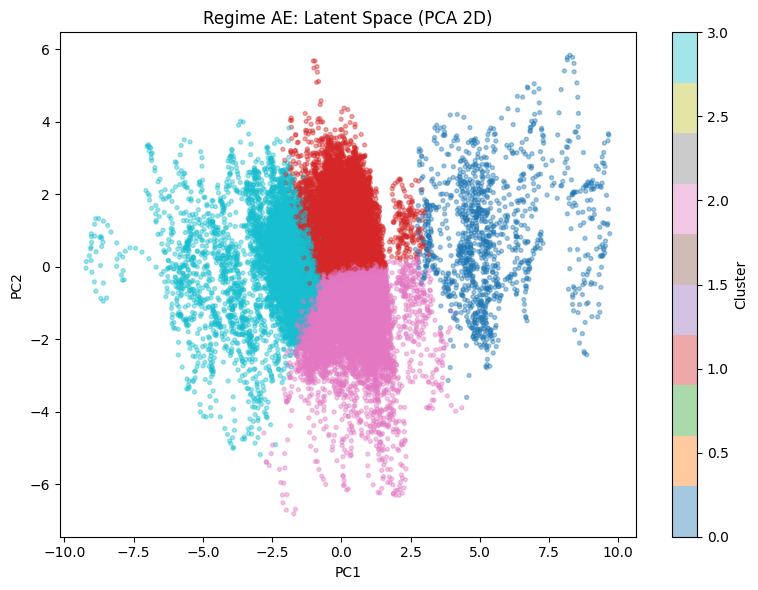

In [ ]:
# PCA visualization of latent space
pca        = PCA(n_components=2)
latents_2d = pca.fit_transform(latents_scaled)

print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}')
print('(>50% means the 2D projection captures most of the latent structure)')

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    latents_2d[:, 0], latents_2d[:, 1],
    c=cluster_labels, cmap='tab10', alpha=0.4, s=8
)
plt.colorbar(scatter, label='Cluster')
plt.title('Regime AE: Latent Space (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

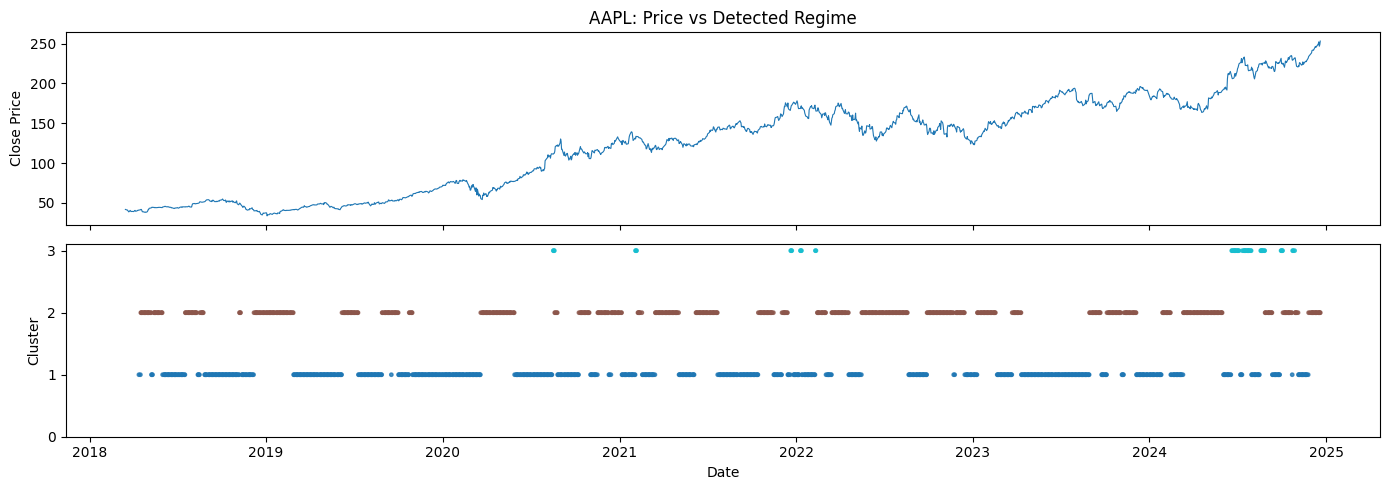

Regime transitions for AAPL: 85
Regime transitions look reasonable.


In [ ]:
# Regime timeline for AAPL — sanity check that regimes shift over time
# and loosely correspond to known market periods
ticker_to_plot = 'AAPL'
ticker_meta    = [(i, t, d) for i, (t, d) in enumerate(metadata) if t == ticker_to_plot]
indices        = [x[0] for x in ticker_meta]
dates          = [x[2] for x in ticker_meta]
regimes        = cluster_labels[indices]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

aapl_close = df[df['ticker'] == ticker_to_plot].set_index('date')['close']
ax1.plot(aapl_close.index, aapl_close.values, linewidth=0.8)
ax1.set_ylabel('Close Price')
ax1.set_title(f'{ticker_to_plot}: Price vs Detected Regime')

ax2.scatter(dates, regimes, c=regimes, cmap='tab10', s=6, alpha=0.8)
ax2.set_ylabel('Cluster')
ax2.set_yticks(range(REGIME['n_clusters']))
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

# Check that regime assignments actually change over time
n_transitions = (np.diff(regimes) != 0).sum()
print(f'Regime transitions for {ticker_to_plot}: {n_transitions}')
assert n_transitions > 5, 'Fewer than 5 regime transitions — model may be stuck in one cluster'
print('Regime transitions look reasonable.')

In [ ]:
# Compare mean returns per cluster for AAPL
aapl_df = df[df["ticker"] == "AAPL"].copy()
regime_labels_aapl = pd.DataFrame(metadata, columns=["ticker","date"])
regime_labels_aapl["cluster"] = cluster_labels
regime_labels_aapl = regime_labels_aapl[regime_labels_aapl["ticker"] == "AAPL"]

merged = aapl_df.merge(regime_labels_aapl, on=["ticker","date"], how="left")
print(merged.groupby("cluster")["target"].agg(["mean","std","count"]))

             mean       std  count
cluster                           
0.0      0.404918  2.004241    638
1.0      0.004798  1.380585     45
2.0      0.204073  1.861461    994


## 9. Attach Regime Labels & Final Data Check

Runs `regime.py` end-to-end and confirms the labeled DataFrame is ready
to feed back into the TFT dataset builder.


In [ ]:
from regime import fit_regimes, attach_regime_labels

cluster_map = fit_regimes(
    ae_model_trained, windows, metadata, df,
    n_clusters = REGIME['n_clusters'],
)

print('\nCluster map:', cluster_map)

Extracted latents: (36894, 8)
Fitting KMeans with 4 clusters on 36894 windows...
Cluster assignments:
  Cluster 0 -> volatile    mean_ret=+0.25325  std=1.90791  n=11572
  Cluster 1 -> bull        mean_ret=+0.10819  std=1.60381  n=8480
  Cluster 2 -> bull        mean_ret=+0.04939  std=1.63154  n=15340
  Cluster 3 -> volatile    mean_ret=+0.55557  std=2.90282  n=1502
Saved regime labels to /content/Market-Lens/data/regime_labels.parquet  (36894 rows)

Cluster map: {0: 'volatile', 1: 'bull', 2: 'bull', 3: 'volatile'}


In [ ]:
df_labeled = attach_regime_labels(df, ae_model_trained, cluster_map, windows, metadata)

print(f'Labeled df shape : {df_labeled.shape}')
print(f'\nRegime distribution:')
print(df_labeled['regime'].value_counts().to_string())

coverage = (df_labeled['regime'] != 'unknown').mean()
print(f'\nCoverage: {coverage:.1%} of rows have a known regime label')

# Final sanity assertions
assert df_labeled.isnull().sum().sum() == 0, 'NaN values found in labeled DataFrame'
assert 'regime' in df_labeled.columns,       'regime column missing'
assert coverage > 0.90,                      f'Coverage too low: {coverage:.1%}'
print('\nAll final data checks passed. DataFrame is ready for TFT training.')

Extracted latents: (36894, 8)
Regime labels attached. Coverage: 98.9% of rows labeled
Regime distribution:
regime
bull        23820
volatile    13074
unknown       418
Labeled df shape : (37312, 60)

Regime distribution:
regime
bull        23820
volatile    13074
unknown       418

Coverage: 98.9% of rows have a known regime label

All final data checks passed. DataFrame is ready for TFT training.


In [ ]:
# Confirm TFT dataset still builds cleanly with the labeled DataFrame
from model import build_timeseries_dataset

train_ds_final, val_ds_final = build_timeseries_dataset(df_labeled, cutoff=VAL_START)

print(f'Train samples : {len(train_ds_final)}')
print(f'Val samples   : {len(val_ds_final)}')
print('TimeSeriesDataSet builds OK on labeled DataFrame.')

Train dataset: 19646 samples
Val dataset:   15026 samples
Train samples : 19646
Val samples   : 15026
TimeSeriesDataSet builds OK on labeled DataFrame.


In [ ]:
from google.colab import userdata
userdata.get('secretName')

SecretNotFoundError: Secret secretName does not exist.

In [ ]:
!pip install streamlit pyngrok -q
from pyngrok import ngrok
import threading, os

ngrok.set_auth_token(NGROK_TOKEN)

def run():
    os.system("streamlit run /content/Market-Lens/app.py --server.port 8501 --server.headless true")

threading.Thread(target=run, daemon=True).start()
import time; time.sleep(3)
print(ngrok.connect(8501))

## 10. Save to Google Drive

In [ ]:
import shutil

DRIVE_SAVE_DIR = '/content/drive/MyDrive/MarketLens_checkpoints'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

files_to_save = {
    str(CHECKPOINT_PATH.parent / 'tft_best.ckpt')   : 'tft_best_15t.ckpt',
    str(MODEL_DIR / 'regime_ae_best.ckpt')           : 'regime_ae_best_15t.ckpt',
    str(DATASET_PATH)                                : 'dataset_15t.parquet',
}

for src, dst_name in files_to_save.items():
    dst = os.path.join(DRIVE_SAVE_DIR, dst_name)
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'Saved: {dst_name}')
    else:
        print(f'MISSING (not saved): {src}')

print(f'\nDrive save directory:')
!ls -lh {DRIVE_SAVE_DIR}